In [4]:
# 1. Load packages
import numpy as np
import pandas as pd
import re
import random

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import StratifiedKFold

import matplotlib.pyplot as plt

In [5]:
# 2. Build the raw text data
random.seed(123)

from gutenbergpy.textget import get_text_by_id

books = {
    "Pride & Prejudice": 1342,
    "Sense & Sensibility": 161,
    "Emma": 158
}

def load_book(book_id):
    text = get_text_by_id(book_id).decode("utf-8", errors="ignore")
    lines = text.split("\n")
    return pd.DataFrame({"text": lines})

dfs = []
for name, bid in books.items():
    df = load_book(bid)
    df["book"] = name
    dfs.append(df)

raw_df = pd.concat(dfs, ignore_index=True)

raw_df = raw_df[
    raw_df["text"].notna() &
    (raw_df["text"].str.strip() != "")
]

raw_df["line_id"] = raw_df.groupby("book").cumcount() + 1

# detect chapters
raw_df["is_chapter"] = raw_df["text"].str.strip().str.lower().str.contains(
    r"^chapter\s+([0-9]+|[ivxlc]+)$", regex=True
)

# chapter_id groups lines → prevents leakage during splitting
raw_df["chapter_id"] = raw_df.groupby("book")["is_chapter"].cumsum()

raw_df = raw_df[raw_df["chapter_id"] > 0]

C:\Users\Dhrumil\AppData\Local\Temp\ipykernel_7032\3531731823.py:33: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  raw_df["is_chapter"] = raw_df["text"].str.strip().str.lower().str.contains(


In [6]:
# 3. Create passage chunks
CHUNK_SIZE = 20  # too large → less variation; too small → weak signal

raw_df["chunk_in_chapter"] = (
    raw_df.groupby(["book","chapter_id"]).cumcount() // CHUNK_SIZE + 1
)

chunk_df = (
    raw_df.groupby(["book","chapter_id","chunk_in_chapter"])["text"]
    .apply(lambda x: " ".join(x))
    .reset_index()
)

chunk_df["text"] = chunk_df["text"].str.replace(r"\s+", " ", regex=True)
chunk_df["nchar_text"] = chunk_df["text"].str.len()

chunk_df = chunk_df[chunk_df["nchar_text"] > 200]
# remove short chunks → not enough information

In [7]:
# 4. Remove overly easy clues
remove_patterns = [
    "elizabeth","darcy","jane","bingley","lydia","wickham","bennet",
    "marianne","elinor","willoughby","edward","brandon","dashwood",
    "lucy","jennings","ferrars","mrs","miss","lady","sir"
]

pattern = r"\b(" + "|".join(remove_patterns) + r")\b"

chunk_df["text"] = (
    chunk_df["text"]
    .str.lower()
    .str.replace(pattern, " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
)

chunk_df["label"] = chunk_df["book"]

print(chunk_df["label"].value_counts())
# shows class balance

label
Emma                   707
Sense & Sensibility    542
Pride & Prejudice      469
Name: count, dtype: int64


In [8]:
# 5. Split by chapter (not chunk)
chapters = chunk_df[["book","chapter_id"]].drop_duplicates()

train_chapters = (
    chapters.groupby("book")
    .sample(frac=0.8, random_state=123)
)
train_chapters["set"] = "train"

df_split = chunk_df.merge(train_chapters, on=["book","chapter_id"], how="left")
df_split["set"] = df_split["set"].fillna("test")

train_df = df_split[df_split["set"] == "train"]
test_df  = df_split[df_split["set"] == "test"]

print(train_df["label"].value_counts())
print(test_df["label"].value_counts())

label
Emma                   573
Sense & Sensibility    542
Pride & Prejudice      469
Name: count, dtype: int64
label
Emma    134
Name: count, dtype: int64


In [9]:
# 6. Tokenization + preprocessing
vectorizer = TfidfVectorizer(
    stop_words="english",   # removes common words
    lowercase=True
)
# removes noise + standardizes text

x_train = vectorizer.fit_transform(train_df["text"])
x_test  = vectorizer.transform(test_df["text"])

y_train = train_df["label"]
y_test  = pd.Categorical(test_df["label"], categories=np.unique(y_train))
# align label levels

In [10]:
# 7. DFM trimming + TF-IDF already handled in vectorizer
vectorizer = TfidfVectorizer(
    stop_words="english",
    min_df=5,     # removes rare words
    max_df=0.8    # removes overly common words
)

x_train = vectorizer.fit_transform(train_df["text"])
x_test  = vectorizer.transform(test_df["text"])
# test must use same vocabulary as training

# TF-IDF emphasizes important words (frequent in doc, rare overall)

In [11]:
# 8. Stratified folds
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
# stratified → keeps same class proportions

In [12]:
# 9. Metrics
def class_metrics(actual, pred):
    classes = np.unique(actual)
    results = []
    
    for cls in classes:
        tp = np.sum((actual == cls) & (pred == cls))
        fp = np.sum((actual != cls) & (pred == cls))
        fn = np.sum((actual == cls) & (pred != cls))
        
        precision = 0 if (tp+fp)==0 else tp/(tp+fp)
        recall    = 0 if (tp+fn)==0 else tp/(tp+fn)
        f1        = 0 if (precision+recall)==0 else 2*precision*recall/(precision+recall)
        
        results.append((cls, precision, recall, f1))
    
    return pd.DataFrame(results, columns=["class","precision","recall","f1"])

def accuracy(actual, pred):
    return np.mean(actual == pred)

def macro_f1(actual, pred):
    return class_metrics(actual, pred)["f1"].mean()

# macro F1 better than accuracy when class imbalance exists

In [13]:
# 10. Grid
grid = [0.01, 0.1, 1, 10]
# C controls regularization
# small C → simpler model
# large C → tighter fit

In [14]:
# 11. Cross-validation
results = []

for C_val in grid:
    accs, f1s = [], []
    
    for train_idx, val_idx in skf.split(x_train, y_train):
        x_tr, x_val = x_train[train_idx], x_train[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        model = LinearSVC(C=C_val)
        model.fit(x_tr, y_tr)
        
        pred_val = model.predict(x_val)
        
        accs.append(accuracy(y_val, pred_val))
        f1s.append(macro_f1(y_val, pred_val))
    
    results.append({
        "C": C_val,
        "cv_accuracy": np.mean(accs),
        "cv_macro_f1": np.mean(f1s)
    })

cv_results = pd.DataFrame(results).sort_values(
    by=["cv_macro_f1","cv_accuracy"], ascending=False
)

print(cv_results)

       C  cv_accuracy  cv_macro_f1
2   1.00     0.955800     0.954143
3  10.00     0.953278     0.951636
1   0.10     0.950745     0.949025
0   0.01     0.843427     0.820505


In [15]:
# 12. Best model
best_C = cv_results.iloc[0]["C"]
# use CV, not test → avoids bias

In [16]:
# 13. Final model
final_model = LinearSVC(C=best_C)
final_model.fit(x_train, y_train)

pred = final_model.predict(x_test)

In [17]:
# 14. Evaluation
conf_mat = confusion_matrix(y_test, pred)
print(conf_mat)

test_accuracy = accuracy(y_test, pred)
test_macro_f1 = macro_f1(y_test, pred)

print("Test accuracy:", round(test_accuracy,4))
print("Test macro F1:", round(test_macro_f1,4))

print(class_metrics(y_test, pred))

print(pd.Series(pred).value_counts())
# shows prediction balance across classes

[[130   4]
 [  0   0]]
Test accuracy: 0.9701
Test macro F1: 0.9848
  class  precision    recall        f1
0  Emma        1.0  0.970149  0.984848
Emma                   130
Sense & Sensibility      4
Name: count, dtype: int64


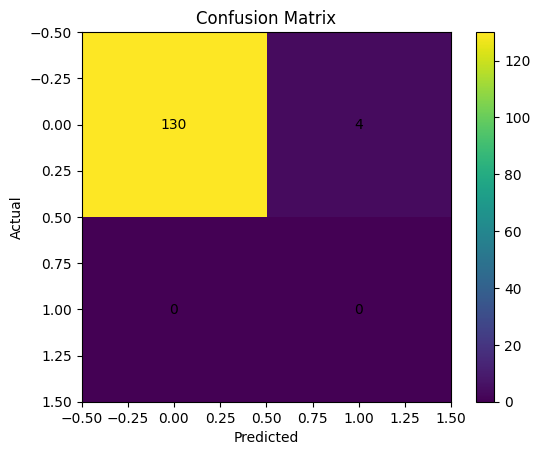

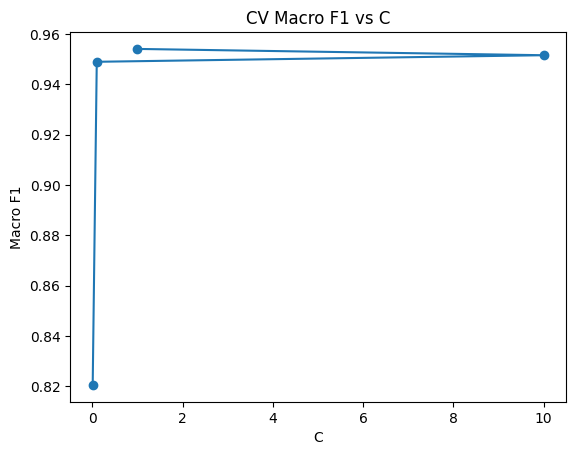

In [20]:
# 15. Plots
fig, ax = plt.subplots()

cax = ax.imshow(conf_mat)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# add numbers inside cells
for i in range(conf_mat.shape[0]):
    for j in range(conf_mat.shape[1]):
        ax.text(j, i, conf_mat[i, j],
                ha="center", va="center")

plt.colorbar(cax)
plt.show()

plt.plot(cv_results["C"], cv_results["cv_macro_f1"])
plt.scatter(cv_results["C"], cv_results["cv_macro_f1"])
plt.title("CV Macro F1 vs C")
plt.xlabel("C")
plt.ylabel("Macro F1")
plt.show()